# 3. Scheduling: Chunked prefill과 prefill–decode interference

글쓴이: [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)), [Claude Code](https://claude.com/claude-code) 🤖

2강은 모든 요청을 prefill 전용 아니면 decode 전용으로 두어 상황을 단순하게 만들었습니다.
실제 요청에는 두 단계가 다 있으므로, serving system은 늘 이런 상황을 마주합니다:

> 여러 사용자가 한창 답변을 받고 있습니다(그 요청들은 **decode 중**입니다). 긴 prompt를
> 가진 새 요청이 도착해서 **prefill**이 필요합니다. Scheduler는 다음에 무엇을 돌려야
> 할까요?

사소해 보이지만, 그 답에 따라 새 사용자가 첫 token을 몇 초씩 기다리게 될 수도 있고,
기존 사용자들의 글이 문장 중간에 **멈춰** 버릴 수도 있습니다. 이 강의에서는 떠오르는
답들을 먼저 시도해 보고, 각각이 왜 실패하는지 본 다음,
vLLM ([Kwon et al., SOSP '23](https://arxiv.org/abs/2309.06180))이나 SGLang
([Zheng et al., NeurIPS '24](https://arxiv.org/abs/2312.07104)) 같은 요즘 serving
system이 쓰는 **chunked prefill**까지 쌓아 올립니다.

:::{admonition} 학습 목표
- 새 prefill을 처리하는 "뻔한" 세 가지 방법(기다리게 하기, decode 멈추기, 함께
  batching하기)이 각각 TTFT나 TPOT 중 하나를 왜 망가뜨리는지 설명할 수 있다.
- Chunked prefill이 어떻게 모든 step의 길이를 제한하는지, 그리고 prefill chunk와 같은
  step에 올라탄 decode가 왜 거의 공짜인지 설명할 수 있다.
- `chunk_size`로 TTFT와 TPOT을 맞바꾸고, 부하가 높을수록 이 trade-off가 왜 더
  날카로워지는지 설명할 수 있다.
:::

## 준비

{doc}`01-prefill-and-decode`와 같은 설정입니다. A100 두 장 위의
Qwen2.5-32B-Instruct.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


## 시나리오

이 강의 전반부에서는 작고 구체적인 시나리오 하나를 계속 씁니다:

- $t = 0$에 **채팅 사용자 16명**이 짧은 prompt(256 token)를 보내고 256 token짜리 답변을
  받기 시작합니다.
- $t = 2$ s에, 16명이 모두 아직 decode 중일 때 **문서** 요청이 도착합니다. prompt는
  3,800 token("이 보고서를 요약해 줘" 같은), 답변은 32 token입니다.

1강과 2강에서 중요한 숫자 두 개를 떠올려 봅시다. 채팅 사용자 16명에 대한 decode step은
약 40 ms가 걸립니다. Decode는 memory-bound여서 요청 16개를 batching해도 하나일 때와
비용이 비슷하기 때문입니다. 3,800 token을 prefill하는 것은 훨씬 오래 걸립니다. Prefill은
compute-bound이고 비용이 prompt 길이에 비례하기 때문입니다. 둘 다 측정해 봅시다:

In [2]:
chat = lsg.simulate(**SYSTEM, qps=None, num_requests=16, prefill_tokens=256, decode_tokens=256)
doc = lsg.simulate(**SYSTEM, qps=None, num_requests=1, prefill_tokens=3800, decode_tokens=1,
                   chunk_size=4096)
decode_step = chat.tpot.median()   # one decode step for the 16 chat users
prefill_time = doc.ttft.iloc[0]    # one 3,800-token prefill, alone on the GPUs
chat_done = chat.e2e.max()         # when the last chat user finishes (no document)
print(f"decode step (16 users): {1e3 * decode_step:.0f} ms")
print(f"prefill of 3,800 tokens: {1e3 * prefill_time:.0f} ms")
print(f"chat users finish at:    {chat_done:.1f} s")

decode step (16 users): 39 ms
prefill of 3,800 tokens: 652 ms
chat users finish at:    10.7 s


Prefill이 decode step보다 약 16배 깁니다. Scheduler가 무엇을 하든 이 650 ms짜리 일은
어딘가에서 처리되어야 합니다. 문제는 **누가 그것을 기다리느냐**입니다.

이 시나리오를 simulator에서 돌리려면 `simulate`의 인자 두 개가 유용합니다.
`arrival_times`는 (주어진 `qps`에 따른 무작위 도착 대신) 각 요청의 정확한 도착 시각을
지정하고, `keep_steps=True`는 GPU가 돌린 모든 forward pass("step")를 기록해서
`r.steps`로 읽을 수 있게 해 줍니다.

In [3]:
def run_scenario(chunk_size):
    """16 chat users from t=0, plus a 3,800-token document arriving at t=2 s."""
    r = lsg.simulate(**SYSTEM, num_requests=17, chunk_size=chunk_size, keep_steps=True,
                     prefill_tokens=[256] * 16 + [3800], decode_tokens=[256] * 16 + [32],
                     arrival_times=[0] * 16 + [2.0])
    steps = r.steps
    # The GPUs are never idle in this scenario, so each step starts when the previous one ends.
    steps["end (s)"] = steps["batch_execution_time"].cumsum()
    steps["start (s)"] = steps["end (s)"] - steps["batch_execution_time"]
    return r, steps

Simulator를 돌리기 전에, 각 정책을 그림으로 스케치해 봅시다. 각 행은 요청 하나입니다.
채팅 사용자 16명 중 3명과 문서 요청이죠. 각 상자는 그 요청이 한 step에서 하는 일입니다.
**decode** 상자는 새 token 하나로 끝나고, **prefill** 상자는 prompt를 처리하며, 회색
상자는 GPU가 다른 일을 하는 동안 그 요청이 **기다리고** 있다는 뜻입니다. 그림은
개념도입니다. 실제 prefill은 decode step 4개가 아니라 약 16개 길이입니다. (궁금하면
눌러서 그리는 코드를 볼 수 있습니다.)

In [4]:
#@title Diagram code (schematic, not to scale)
from matplotlib.patches import Patch

def draw_schedule(policy, title):
    """Sketch one scheduling policy. Time unit: one decode step."""
    PREFILL, CHUNK_STEP, N_CHUNKS = 4.0, 1.5, 3   # whole prefill, one chunked step, chunks
    ARRIVAL, DOC_TOKENS = 2.0, 4
    left = [6, 7, 8]                  # output tokens still to produce, per chat user
    DOC = len(left)                   # row of the document
    boxes, t, chunks_done, doc_left, first_token = [], 0.0, 0, DOC_TOKENS, None
    while any(left) or doc_left:
        need_prefill = t >= ARRIVAL and chunks_done < N_CHUNKS
        chat, doc, length = "decode", None, 1.0
        if need_prefill and policy == "wait" and any(left):
            doc = "waiting"
        elif need_prefill and policy == "chunked":
            doc, length = f"chunk {chunks_done + 1}", CHUNK_STEP
        elif need_prefill:
            doc, length = "prefill (whole prompt)", PREFILL
            chat = "paused" if policy == "pause" else "decode"
        elif chunks_done == N_CHUNKS and doc_left:
            doc = "decode"
        for i, n in enumerate(left):
            if n:
                boxes.append((i, t, length, chat))
                left[i] -= chat == "decode"
        if doc:
            boxes.append((DOC, t, length, doc))
            if doc.startswith(("prefill", "chunk")):
                chunks_done = N_CHUNKS if doc.startswith("prefill") else chunks_done + 1
                if chunks_done == N_CHUNKS:
                    first_token, doc_left = t + length, doc_left - 1
            elif doc == "decode":
                doc_left -= 1
        t += length

    color = {"decode": "C1", "paused": "0.85", "waiting": "0.85"}
    fig, ax = plt.subplots(figsize=(10, 2.7))
    merged = []                      # merge a row's consecutive waiting boxes into one
    for b in boxes:
        prev = [j for j, m in enumerate(merged) if m[0] == b[0]]
        if prev and b[3] == merged[prev[-1]][3] == "waiting":
            row, start, length, kind = merged[prev[-1]]
            merged[prev[-1]] = (row, start, length + b[2], kind)
        else:
            merged.append(b)
    for row, start, length, kind in merged:
        ax.barh(row, length - 0.06, left=start, height=0.6, color=color.get(kind, "C0"),
                hatch="//" if kind in ("paused", "waiting") else None, edgecolor="white")
        label = {"decode": "1 token" if length > 2 else ""}.get(kind, kind)
        if label:
            ax.text(start + length / 2, row, label, ha="center", va="center", fontsize=8,
                    color="white" if kind.startswith(("prefill", "chunk", "decode")) else "k")
    ax.axvline(ARRIVAL, color="k", ls=":", lw=1)
    ax.text(ARRIVAL, -0.75, "document arrives ", ha="right", va="center", fontsize=8)
    ax.annotate("", (ARRIVAL, DOC + 0.55), (first_token, DOC + 0.55),
                arrowprops=dict(arrowstyle="<->", color="C0"))
    ax.text((ARRIVAL + first_token) / 2, DOC + 0.8, "document's TTFT", ha="center",
            va="center", fontsize=8, color="C0")
    gap = PREFILL if policy in ("pause", "mixed") else CHUNK_STEP if policy == "chunked" else 1.0
    ax.annotate("", (ARRIVAL, -0.45), (ARRIVAL + gap, -0.45),
                arrowprops=dict(arrowstyle="<->", color="C3"))
    ax.text(ARRIVAL + gap + 0.1, -0.45, "chat users' gap between tokens", ha="left",
            va="center", fontsize=8, color="C3")
    ax.set(xlim=(0, 16), ylim=(DOC + 1.1, -1.05), yticks=range(DOC + 1),
           yticklabels=[f"chat user {i + 1}" for i in range(DOC)] + ["document"],
           xticks=[], xlabel="time →", title=title)
    ax.grid(False)
    ax.legend(handles=[Patch(color="C0", label="prefill"), Patch(color="C1", label="decode (1 token)"),
                       Patch(facecolor="0.85", hatch="//", edgecolor="white", label="waiting")],
              loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8)
    fig.tight_layout()

## 만약... 새 요청이 기다린다면?

가장 단순한 정책입니다. 이미 돌고 있는 요청들이 끝날 때까지 두고, 그다음에야 새 요청을
시작합니다. NVIDIA의
[FasterTransformer](https://github.com/NVIDIA/FasterTransformer) 같은 초기 serving
system이 이렇게 동작했습니다(*request-level batching*). 한 batch의 요청들이 모두 끝날
때까지 함께 돌고, 그다음에야 다음 batch를 만들었죠.

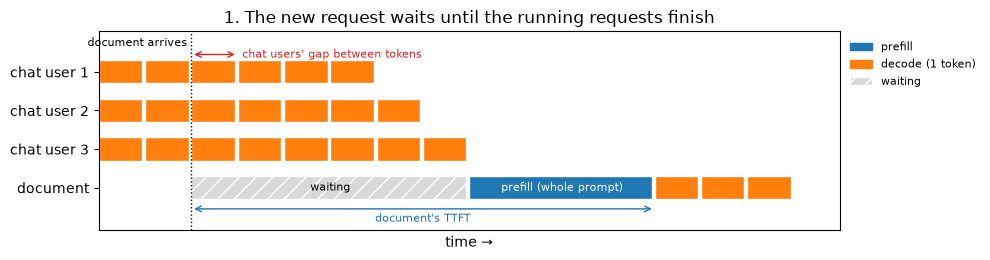

In [5]:
#@title Diagram
draw_schedule("wait", "1. The new request waits until the running requests finish")

채팅 사용자들은 만족합니다. 아무것도 방해하지 않고, 약 40 ms마다 token을 계속 받습니다.
하지만 문서 요청은 *마지막* 채팅 사용자가 끝날 때까지 prefill조차 시작하지 못합니다.
게다가 채팅 사용자가 하나씩 끝나면서 batch가 줄어들어, GPU는 step마다 점점 더 적은 일을
하게 됩니다. 우리 시나리오에서 문서 요청의 TTFT는 이렇게 됩니다:

In [6]:
ttft_wait = (chat_done - 2.0) + prefill_time
print(f"document TTFT if it waits: {ttft_wait:.1f} s")

document TTFT if it waits: 9.3 s


사용자가 요약의 첫 단어를 보기까지 9초가 넘고, 그 시간의 거의 전부가 계산이 아니라
기다림입니다. 바쁜 서버에서는 더 나쁩니다. *언제나* 누군가는 decode 중이므로, 새 요청이
무한정 기다릴 수도 있습니다(*starvation*).

**판정: TPOT은 훌륭, TTFT는 최악.**

## 만약... decode를 멈추고 바로 prefill한다면?

정반대의 정책입니다. 새 요청이 도착하자마자 decode 중인 모두를 멈추고, 새 요청의
prefill만 따로 돌린 뒤 decode를 재개합니다. 이 *prefill-first* 정책은
vLLM ([Kwon et al., SOSP '23](https://arxiv.org/abs/2309.06180))의 V1 엔진 이전
기본값이었습니다.

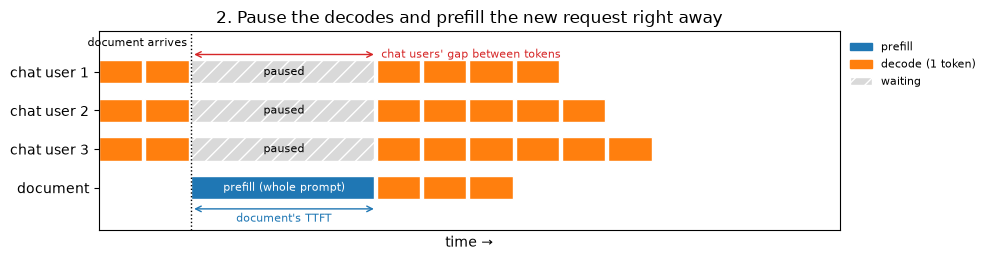

In [7]:
#@title Diagram
draw_schedule("pause", "2. Pause the decodes and prefill the new request right away")

이제 문서 요청은 첫 token을 빨리 받습니다. 현재 decode step이 끝나기만 기다렸다가 650
ms짜리 prefill을 돌리면 되니까요. 하지만 그 prefill이 도는 동안 **16명의 채팅 사용자는
아무도 token을 받지 못합니다**. 각 사용자 입장에서는 글이 흐르다가 얼어붙습니다:

In [8]:
stall_pause = prefill_time + decode_step  # no token during the prefill, then the next decode step
print(f"document TTFT: ~{prefill_time:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * stall_pause:.0f} ms "
      f"(normally {1e3 * decode_step:.0f} ms)")

document TTFT: ~0.65 s
longest gap between two tokens for a chat user: 691 ms (normally 39 ms)


문장 한가운데서 0.7초가 멈추는 것은 아주 잘 느껴지고, 한 번으로 끝나지도 않습니다.
실제 서버에서는 긴 prompt가 계속 도착하고, 그때마다 *그 순간 decode 중인 모든* 사용자가
얼어붙습니다. 이를 **generation stall**이라고 부르며, tail (p99) TPOT으로 드러납니다.

**판정: TTFT는 좋지만, 새 prefill마다 나머지 전부를 멈춰 세운다.**

## 만약... prefill과 decode를 같이 batching한다면?

2강에서 batching이 효율의 핵심임을 보았습니다. 그러면 새 prefill과 16개의 decode를
*같은* step에 넣으면 어떨까요? 그러면 decode들은 prefill 동안 멈추는 대신 진도를 나갈 수
있습니다. 한 step 단위로 scheduling하는 방식(*iteration-level scheduling*)을 처음
제안한 Orca ([Yu et al., OSDI '22](https://www.usenix.org/conference/osdi22/presentation/yu))가
이런 혼합 batch를 만들 수 있었습니다.

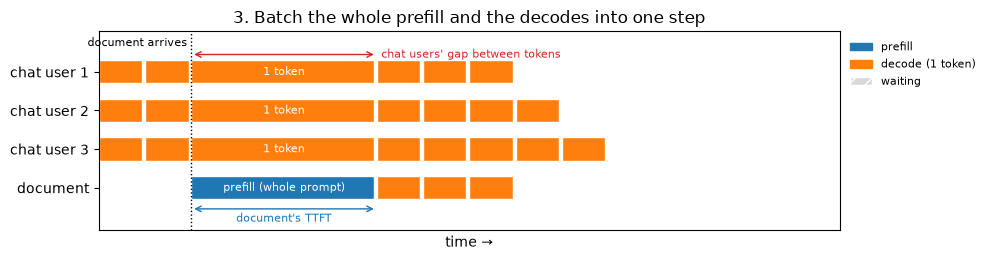

In [9]:
#@title Diagram
draw_schedule("mixed", "3. Batch the whole prefill and the decodes into one step")

이제 채팅 사용자들은 그 긴 step에서 아무것도 못 받는 대신 token 하나씩은 받습니다.
하지만 step 자체가 prefill 전체만큼 길기 때문에, token 사이의 간격은 정책 2와 똑같이
길어집니다.

Simulator의 scheduler도 step당 token 예산(`chunk_size`)이 prompt 전체를 담을 만큼 크면
(예: 4,096 token) 이렇게 동작합니다. $t = 2$ s 부근의 step들을 보죠:

In [10]:
r_mixed, steps_mixed = run_scenario(chunk_size=4096)
cols = ["start (s)", "end (s)", "batch_num_prefill_tokens", "batch_num_decode_tokens",
        "batch_execution_time"]
steps_mixed[(steps_mixed["end (s)"] > 1.95) & (steps_mixed["start (s)"] < 2.8)][cols].round(3)

,start (s),end (s),batch_num_prefill_tokens,batch_num_decode_tokens,batch_execution_time
35,1.945,1.983,0,16,0.038
36,1.983,2.021,0,16,0.038
37,2.021,2.674,3800,16,0.653
38,2.674,2.710,0,17,0.036
39,2.710,2.746,0,17,0.036
40,2.746,2.781,0,17,0.036
41,2.781,2.817,0,17,0.036


각 행이 한 step입니다. 문서 요청이 도착하기 전에는 매 step이 약 38 ms에 16개
token(채팅 사용자당 하나)을 decode합니다. 그다음 한 step이 3,800개의 prompt token을
**전부** 처리하면서 decode token 16개도 함께 처리하고, 약 650 ms가 걸립니다. 그 뒤로는
문서 요청도 decode에 합류합니다(step당 17개).

두 가지를 관찰할 수 있습니다:

1. **Decode는 거의 공짜로 얹혀 갑니다.** 혼합 step은 prefill만 했을 때와 거의 같은
   시간이 걸립니다(위에서 측정한 652 ms와 비교해 보세요). Prefill이 연산 유닛을 바쁘게
   쓰고 있어서, token 16개가 더 붙어도 거의 보태지 않습니다.
2. **하지만 멈춤은 그대로입니다.** 채팅 사용자는 그 650 ms짜리 step에서 여전히 token
   하나만 받습니다. Step은 그 안에서 가장 큰 일이 끝나기 전에는 끝날 수 없고, batch 안의
   모든 요청은 가장 느린 것의 속도로 움직입니다.

In [11]:
gap_mixed = steps_mixed["batch_execution_time"].max()
print(f"document TTFT: {r_mixed.ttft.iloc[16]:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * gap_mixed:.0f} ms")

document TTFT: 0.67 s
longest gap between two tokens for a chat user: 653 ms


**판정: 멈추는 것보다 약간 낫지만, 멈춤은 그대로다.**

## 우리가 원하는 것은 무엇인가

세 가지 시도를 돌아보면:

| 정책 | 문서 TTFT | 채팅 사용자의 최대 간격 | 문제 |
|---|---|---|---|
| 1. 새 요청이 기다린다 | 약 9 s | 약 40 ms | 새 요청이 굶는다 |
| 2. decode를 멈추고 prefill 먼저 | 약 0.7 s | 약 690 ms | 모두가 멈춘다 |
| 3. prefill과 decode를 함께 batching | 약 0.7 s | 약 650 ms | 여전히 모두가 멈춘다 |

정책 2와 3의 근본 원인은 같습니다. 긴 prompt 전체가 한 step에 들어가서 **step 하나가 너무
길다**는 것이죠. 정책 1은 새 요청의 진도를 아예 멈춤으로써만 긴 step을 피합니다. 우리가
원하는 것은:

- **모든 step이 짧게 유지되어서** decode 중인 사용자가 일정한 속도로 token을 계속 받고,
- **모든 step이 prefill에도 진도를 내서** 새 요청이 굶지 않는 것입니다.

## 해결책: chunked prefill

Prompt를 한 step에 다 prefill해야 할 이유는 없습니다. Prompt를 **chunk**로 쪼개서 여러
step에 나눠 처리할 수 있습니다. 첫 chunk는 앞쪽 token들의 KV cache를 계산하고, 다음
chunk는 그 캐시된 KV를 attend하면서 자기 것을 덧붙이고, 이런 식입니다. 결과는 prompt
전체를 한 번에 prefill한 것과 정확히 같습니다(decode가 앞선 token들을 attend하는 것과
같은 메커니즘입니다).

Sarathi-Serve ([Agrawal et al., OSDI '24](https://www.usenix.org/conference/osdi24/presentation/agrawal))가
제안하고 이제 vLLM과 SGLang에서 기본으로 쓰이는 **chunked prefill**은, 고정된 **token
예산**(우리 simulator에서는 `chunk_size`) 아래에서 매 step을 구성합니다:

1. decode 중인 모든 요청이 먼저 다음 token을 받습니다(각각 1 token).
2. 남은 예산은 prefill에 돌아갑니다. 남은 예산보다 긴 prompt는 잘리고, 나머지는 다음
   step에서 이어집니다.

앞서와 같은 그림으로 보면:

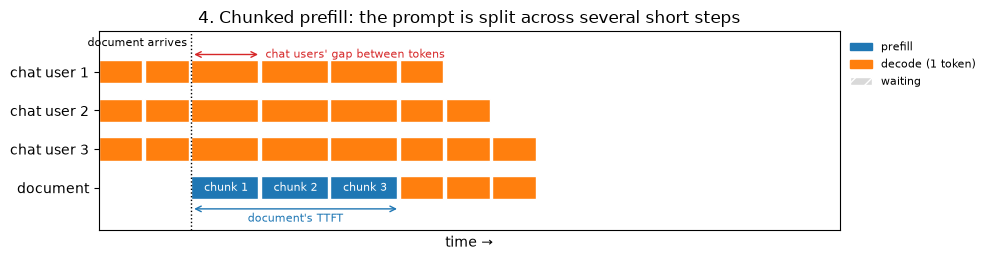

In [12]:
#@title Diagram
draw_schedule("chunked", "4. Chunked prefill: the prompt is split across several short steps")

이제 매 step에는 prefill의 조각 *하나*와 채팅 사용자 전원의 token 하나씩이 함께
들어갑니다. 각 step은 순수 decode step보다 조금 길지만 어느 것도 길지 않고, 문서 요청도
매 step마다 진도를 냅니다. 대가는 문서의 첫 token이 조금 늦어지는 것입니다. Prefill이
여러 step에 흩어지니까요.

예산을 512 token으로 두면, 우리 시나리오의 각 step에는 decode token 16개와 문서의 496
token짜리 chunk가 들어갑니다:

In [13]:
r_chunk, steps_chunk = run_scenario(chunk_size=512)
steps_chunk[(steps_chunk["end (s)"] > 1.95) & (steps_chunk["start (s)"] < 2.9)][cols].round(3)

,start (s),end (s),batch_num_prefill_tokens,batch_num_decode_tokens,batch_execution_time
37,1.940,1.978,0,16,0.038
38,1.978,2.017,0,16,0.038
39,2.017,2.120,496,16,0.103
40,2.120,2.224,496,16,0.104
41,2.224,2.329,496,16,0.105
42,2.329,2.434,496,16,0.106
43,2.434,2.541,496,16,0.107
44,2.541,2.649,496,16,0.108
45,2.649,2.758,496,16,0.109
46,2.758,2.843,328,16,0.085


In [14]:
gap_chunk = steps_chunk["batch_execution_time"].max()
print(f"document TTFT: {r_chunk.ttft.iloc[16]:.2f} s")
print(f"longest gap between two tokens for a chat user: {1e3 * gap_chunk:.0f} ms")

document TTFT: 0.84 s
longest gap between two tokens for a chat user: 109 ms


이제 문서는 약 105 ms짜리 step 8번에 걸쳐 prefill됩니다. 채팅 사용자는 650 ms 동안
얼어붙는 대신 약 105–110 ms마다 token을 계속 받고, 문서의 TTFT는 약 0.67초에서 0.84초로
조금 늘어날 뿐입니다.

전체 비용이 왜 이렇게 작을까요? Step 시간을 보세요. 512 token짜리 step은 약 105 ms로,
512 token만 prefill할 때와 비슷한데(2강), 거기에 decode token 16개까지 만들어 냅니다.
그 16개만 따로 하면 약 38 ms짜리 step이 필요했을 텐데 말이죠. Prefill chunk는 연산
유닛을 바쁘게 쓰고, decode는 weight를 읽느라 메모리 대역폭을 쓰므로, **둘을 섞은 step은
양쪽을 다 씁니다**. Chunked prefill은 긴 step 없이 정책 3의 batching 효율을 가져옵니다.

:::{admonition} 직접 해보기
:class: exercise
시나리오의 3,800 token짜리 문서를 1,000 token짜리로 바꿔 보세요. `chunk_size=4096`일 때
멈춤은 얼마나 긴가요? 512일 때는요? chunking이 여전히 값어치를 하나요?
:::

## Chunk size 고르기

Token 예산은 knob이고, 한쪽 latency를 다른 쪽과 맞바꿉니다:

- 예산이 **작으면** 모든 step이 짧아져서 decode 중인 사용자가 느끼는 간격이 줄어듭니다.
  하지만 prompt가 더 많은 step으로 쪼개지고, 모든 step에는 고정 비용이 있습니다. token을
  몇 개만 처리하더라도 weight는 메모리에서 전부 읽어야 하니까요. 그래서 prefill 전체는
  더 오래 걸리고 TTFT가 늘어납니다.
- 예산이 **크면** prefill은 빨라지지만 step이 길어집니다. 4,096이면 3,800 token짜리
  prompt가 한 step에 들어가서 정책 3으로 되돌아갑니다.

여러 예산으로 시나리오를 돌려 봅시다:

In [15]:
rows = []
for c in [128, 256, 512, 1024, 2048, 4096]:
    r, st = run_scenario(chunk_size=c)
    rows.append({"chunk_size": c, "document TTFT (s)": r.ttft.iloc[16],
                 "chat users' longest gap (ms)": 1e3 * st["batch_execution_time"].max()})
budget = pd.DataFrame(rows).set_index("chunk_size")
budget.round(2)

,document TTFT (s),chat users' longest gap (ms)
chunk_size,,
128,1.59,47.52
256,1.06,64.95
512,0.84,109.30
1024,0.76,190.04
2048,0.67,342.25
4096,0.67,653.26


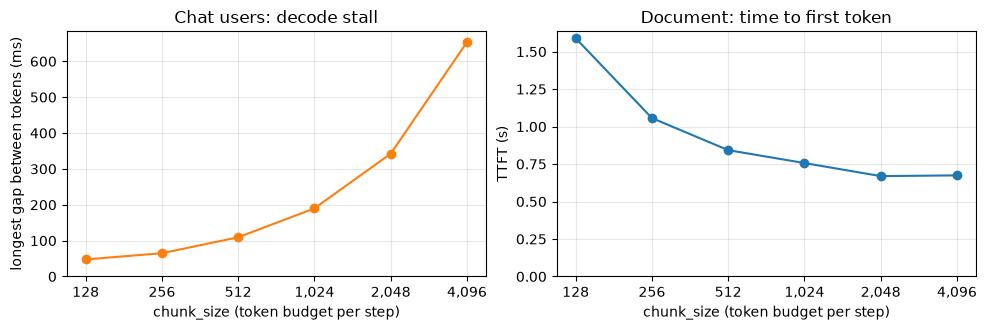

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(budget.index, budget["chat users' longest gap (ms)"], "o-", color="C1")
ax[0].set(ylabel="longest gap between tokens (ms)", title="Chat users: decode stall")
ax[1].plot(budget.index, budget["document TTFT (s)"], "o-", color="C0")
ax[1].set(ylabel="TTFT (s)", title="Document: time to first token")
for a in ax:
    a.set_xscale("log", base=2)
    a.set_xticks(budget.index, [f"{c:,}" for c in budget.index])
    a.minorticks_off()
    a.set_xlabel("chunk_size (token budget per step)")
    a.set_ylim(bottom=0)
fig.tight_layout()

4,096에서 512로 내려오면 멈춤이 약 6배 줄고 TTFT는 조금만 늘어납니다. 그 아래로는 효과가
줄어듭니다. Step은 순수 decode step(약 38 ms)보다 짧아질 수 없는데, 고정 비용을 점점 더
여러 번 내게 되므로 TTFT는 계속 늘어나기 때문입니다. 실제로는 수백에서 수천 token 정도의
예산을 많이 씁니다.

## 실제 부하에서

위 시나리오에는 긴 prompt가 하나뿐이었습니다. 실제 서버에는 요청이 계속 도착합니다. 이제
섞인 workload를 simulation해 봅시다. 요청의 85%는 채팅 turn(입력 256 token, 출력 256
token), 15%는 문서(입력 3,800 token, 출력 32 token)이고 무작위 순서로 도착합니다.
`lsg.make_trace`가 요청별 길이를 trace 파일로 써 주면 simulator가 그것을 재현합니다.

In [17]:
rng = np.random.default_rng(0)
n = 300
is_long = rng.random(n) < 0.15
trace = lsg.make_trace(prefill_tokens=np.where(is_long, 3800, 256),
                      decode_tokens=np.where(is_long, 32, 256), n=n, name="mixed")
pd.read_csv(trace).value_counts().rename("requests")

num_prefill_tokens  num_decode_tokens
256                 256                  255
3800                32                    45
Name: requests, dtype: int64

중간 부하(2 req/s)와 높은 부하(4 req/s)에서, `chunk_size`를 step당 128부터 4,096
token까지 쓸어 가며 trace를 돌립니다. 멈춤은 일부 token만 때리므로 **tail**을 봅니다.
p99 TPOT, 즉 평균 간격 기준으로 가장 느린 1%의 요청입니다. (강의 끝에서 이 지표조차
멈춤을 과소평가한다는 것을 보게 됩니다.)

In [18]:
chunks = [128, 256, 512, 1024, 2048, 4096]
cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "TPOT p99 (ms)", "throughput (tok/s)"]
res = {q: lsg.sweep("chunk_size", chunks, **SYSTEM, trace=trace, num_requests=n, qps=q)
       for q in (2, 4)}
res[4][cols].round(0)

,TTFT p50 (ms),TTFT p99 (ms),TPOT p50 (ms),TPOT p99 (ms),throughput (tok/s)
chunk_size,,,,,
128.0,22588.0,41675.0,46.0,47.0,2541.0
256.0,5961.0,10664.0,65.0,66.0,3449.0
512.0,988.0,2993.0,83.0,103.0,3836.0
1024.0,570.0,2074.0,87.0,144.0,3856.0
2048.0,408.0,1763.0,87.0,158.0,3856.0
4096.0,423.0,2088.0,91.0,164.0,3854.0


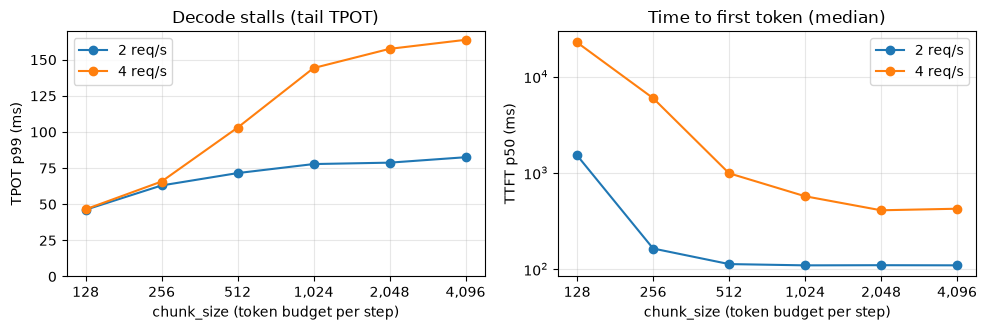

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for q, df in res.items():
    ax[0].plot(chunks, df["TPOT p99 (ms)"], "o-", label=f"{q} req/s")
    ax[1].plot(chunks, df["TTFT p50 (ms)"], "o-", label=f"{q} req/s")
ax[0].set(ylabel="TPOT p99 (ms)", title="Decode stalls (tail TPOT)", ylim=(0, None))
ax[1].set(ylabel="TTFT p50 (ms)", title="Time to first token (median)", yscale="log")
for a in ax:
    a.set_xscale("log", base=2)
    a.set_xticks(chunks, [f"{c:,}" for c in chunks])
    a.minorticks_off()
    a.set_xlabel("chunk_size (token budget per step)")
    a.legend()
fig.tight_layout()

높은 부하(4 req/s) 곡선을 오른쪽에서 왼쪽으로 읽어 봅시다:

- **큰 예산(4,096).** 모든 문서가 한 step에 prefill되므로, 문서마다 옆에서 decode 중인
  모든 사용자를 멈춰 세웁니다. p99 TPOT은 순수 decode step의 약 4배입니다.
- **중간 예산(512).** 문서가 약 8개의 chunk로 쪼개집니다. p99 TPOT이 약 40% 줄고, 중앙값
  TTFT는 대략 두 배가 되지만 1초 아래에 머뭅니다.
- **아주 작은 예산(128, 256).** 멈춤은 거의 사라지지만, step이 너무 작아져서 고정 비용이
  지배합니다. GPU가 token 몇 개를 처리하려고 weight를 읽는 데 시간을 대부분 씁니다.
  Prefill throughput이 새 prompt가 도착하는 속도보다 낮아져 요청이 queue에 쌓이고, TTFT는
  수 초 단위로 폭발합니다.

2 req/s에서는 GPU에 여유가 있어서 아주 작은 chunk(128 제외)로도 따라갈 수 있고, 도착하는
문서가 적어 멈춤도 덜합니다. **Scheduling은 시스템이 바쁠 때 가장 중요하고**, 하필 그때가
예산을 고르기 가장 어려운 때이기도 합니다.

:::{admonition} 직접 해보기
:class: exercise
1. 섞인 workload에서 문서의 비율을 40%로 올려 보세요. p99 TPOT 기준 최적 `chunk_size`가
   달라지나요?
2. SLO가 p99 TTFT < 2 s **그리고** p99 TPOT < 100 ms라고 합시다. 감당할 수 있는 가장 큰
   `qps`와, 그것을 달성하는 `chunk_size`를 찾아보세요.
:::

## TPOT vs. TBT: 평균이 숨기는 것

지금까지 decode 속도를 TPOT으로 재 왔습니다. TPOT이 무엇인지 정확히 해 둘 필요가
있습니다. **요청당 숫자 하나**, 그 요청의 output token 사이 간격의 *평균*입니다. 위에서
"TPOT p99"라고 쓴 것은 *요청들 사이의* 99 percentile, 즉 각자의 평균으로 판단했을 때 가장
느린 1%의 사용자를 뜻합니다.

그런데 사용자는 평균을 경험하지 않습니다. 글이 token 하나씩 도착하는 것을 보고, 모든
개별 간격을 겪습니다. 각 output token 앞의 간격을 **time between tokens (TBT)**라고
합니다. Output이 256 token인 요청은 TPOT은 하나지만 TBT는 255개입니다. 그 자체로 하나의
분포이고, TPOT은 그 평균일 뿐이죠. (이 강의 앞부분 시나리오에서 잰 "최대 간격"이 바로
채팅 사용자의 가장 큰 TBT였습니다.)

4 req/s에서 중간 예산과 가장 큰 예산일 때의 TBT를 봅시다. 기록된 step에서 계산할 수
있습니다. 이 부하에서는 GPU가 노는 일이 없어 step들이 연달아 돌고, 각 요청은 첫 token과
마지막 token 사이에 step마다 token 하나씩을 받습니다. 그 요청의 TBT는 그냥 그 step들의
길이입니다.

In [20]:
loaded = {c: lsg.simulate(**SYSTEM, trace=trace, num_requests=n, qps=4, chunk_size=c,
                          keep_steps=True) for c in (512, 4096)}

def tbt_per_request(r):
    """The gap before each output token (s): one array per request."""
    dur = r.steps["batch_execution_time"].values
    end = r.requests["request_arrived_at"].min() + dur.cumsum()   # steps run back to back
    first = (r.requests["request_arrived_at"] + r.requests["prefill_e2e_time"]).values
    last = (r.requests["request_arrived_at"] + r.requests["request_e2e_time"]).values
    # The steps that produced each request's first and last token.
    i = np.abs(end[None, :] - first[:, None]).argmin(axis=1)
    j = np.abs(end[None, :] - last[:, None]).argmin(axis=1)
    return [dur[a + 1:b + 1] for a, b in zip(i, j)]

tbt = {c: tbt_per_request(r) for c, r in loaded.items()}

# Sanity check: each request's gaps add up to its decode time (= TPOT x output tokens).
for c, r in loaded.items():
    decode_time = r.tpot * r.requests["request_num_decode_tokens"]
    err = max(abs(g.sum() - d) for g, d in zip(tbt[c], decode_time))
    print(f"chunk_size={c}: largest mismatch {1e3 * err:.3f} ms")

chunk_size=512: largest mismatch 0.138 ms
chunk_size=4096: largest mismatch 0.156 ms


### 사용자 한 명의 시점

전형적인 채팅 사용자 한 명을 골라 봅시다. `chunk_size=4096`일 때 채팅 요청 중 TPOT이
중앙값인 사용자입니다. 두 실행은 같은 trace를 재현하므로, *같은* 사용자를 두 예산에서
따라가며 각 token 앞의 간격을 그릴 수 있습니다:

chunk_size=4096: TPOT 91 ms, longest gap 724 ms, 15 gaps longer than 0.5 s
chunk_size=512: TPOT 87 ms, longest gap 109 ms, 0 gaps longer than 0.5 s


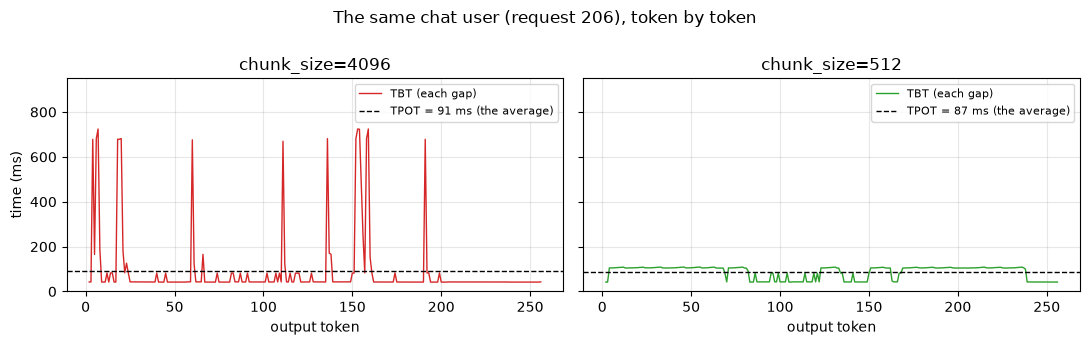

In [21]:
is_chat = loaded[4096].requests["request_num_prefill_tokens"].values < 1000
chat_ids = np.where(is_chat)[0]
user = chat_ids[np.argsort(loaded[4096].tpot.values[chat_ids])[len(chat_ids) // 2]]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, (c, color) in zip(ax, ((4096, "C3"), (512, "C2"))):
    gaps, tpot = 1e3 * tbt[c][user], 1e3 * loaded[c].tpot[user]
    a.plot(np.arange(2, len(gaps) + 2), gaps, color=color, lw=1, label="TBT (each gap)")
    a.axhline(tpot, color="k", ls="--", lw=1, label=f"TPOT = {tpot:.0f} ms (the average)")
    a.legend(loc="upper right", fontsize=8)
    a.set(xlabel="output token", title=f"chunk_size={c}", ylim=(0, 950))
    print(f"chunk_size={c}: TPOT {tpot:.0f} ms, longest gap {gaps.max():.0f} ms, "
          f"{(gaps > 500).sum()} gaps longer than 0.5 s")
ax[0].set_ylabel("time (ms)")
fig.suptitle(f"The same chat user (request {user}), token by token", y=1.0)
fig.tight_layout()

`chunk_size=4096`에서 이 사용자의 TPOT은 약 90 ms입니다. 액면 그대로 보면 조금 느리지만
꾸준한 흐름처럼 들립니다. 그런데 그래프는 전혀 다른 이야기를 합니다. 대부분의 token은 약
40 ms 만에 도착하지만, 다른 사용자의 문서가 prefill될 때마다 글이 **약 0.7초씩
얼어붙고**, 그것이 답변 하나 동안 몇 번이고 반복됩니다. 90 ms 근처인 개별 간격은 하나도
없습니다. 평균은 아주 빠른 것과 아주 느린 것이 섞인 결과일 뿐입니다.

`chunk_size=512`에서는 TPOT이 거의 같은데도(91 ms 대신 87 ms) 경험은 완전히 다릅니다.
간격이 약 40 ms와 약 105 ms 사이를 오갈 뿐, 글이 얼어붙지 않습니다. TPOT은 이 두 사용자를
거의 구분하지 못합니다.

이 사용자가 운이 나빴던 것도 아닙니다. 채팅 사용자 전체를 보면:

In [22]:
rows = {}
for c, r in loaded.items():
    longest = np.array([g.max() for g in tbt[c]])[chat_ids]
    freezes = np.array([(g > 0.5).sum() for g in tbt[c]])[chat_ids]
    rows[f"chunk_size={c}"] = {
        "TPOT p50 (ms)": round(1e3 * np.median(r.tpot.values[chat_ids])),
        "TPOT p99 (ms)": round(1e3 * np.percentile(r.tpot.values[chat_ids], 99)),
        "longest gap per user, p50 (ms)": round(1e3 * np.median(longest)),
        "users with a freeze > 0.5 s": f"{(freezes > 0).mean():.0%}",
        "freezes per user, p50": int(np.median(freezes)),
    }
pd.DataFrame(rows)

,chunk_size=512,chunk_size=4096
TPOT p50 (ms),82,91
TPOT p99 (ms),96,108
"longest gap per user, p50 (ms)",109,724
users with a freeze > 0.5 s,0%,99%
"freezes per user, p50",0,15


Chunking이 없으면 채팅 사용자의 *p99* TPOT, 즉 평균 기준 최악의 1%조차 100 ms 근처에
머뭅니다. 그런데 거의 모든 채팅 사용자가 0.5초가 넘는 멈춤을 열 번 넘게 겪습니다. 이
사용자들 중 누구도 긴 prompt를 보내지 않았습니다. 모든 멈춤은 *다른 사용자의*
prefill 때문입니다. 요청 사이의 이런 **interference**가 공유 GPU에서 latency를 보장하기
어렵게 만드는 이유입니다.

### 모든 token을 한꺼번에: TBT 분포

사용자 한 명 대신, 모든 요청의 모든 token의 TBT를 모아 분포를 볼 수 있습니다.
**누적분포함수**(CDF)가 이를 한눈에 보여 줍니다. x축의 각 간격 길이에 대해, 간격이 그보다
짧거나 같았던 token의 비율을 알려 줍니다. 가파르고 일찍 올라가는 곡선은 간격이 일관되게
짧다는 뜻이고, 오른쪽으로 길게 기어가며 1에 닿는 곡선은 긴 기다림의 tail이 있다는
뜻입니다.

chunk_size=512: TBT p50 104 ms, p99 109 ms, tokens waiting > 0.3 s: 0.0%
chunk_size=4096: TBT p50 42 ms, p99 706 ms, tokens waiting > 0.3 s: 5.6%


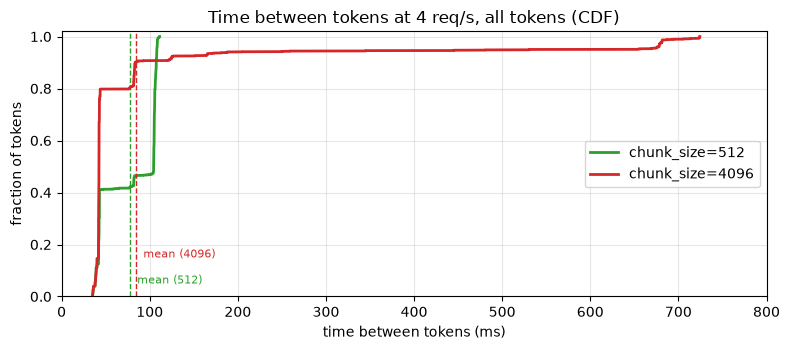

In [23]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for c, color in ((512, "C2"), (4096, "C3")):
    x = np.sort(1e3 * np.concatenate(tbt[c]))
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), color=color, lw=2, label=f"chunk_size={c}")
    ax.axvline(x.mean(), color=color, ls="--", lw=1)
    ax.text(x.mean() + 8, 0.05 if c == 512 else 0.15, f"mean ({c})", color=color, fontsize=8)
    print(f"chunk_size={c}: TBT p50 {np.percentile(x, 50):.0f} ms, p99 {np.percentile(x, 99):.0f} ms, "
          f"tokens waiting > 0.3 s: {(x > 300).mean():.1%}")
ax.set(xlabel="time between tokens (ms)", ylabel="fraction of tokens", xlim=(0, 800),
       ylim=(0, 1.02), title="Time between tokens at 4 req/s, all tokens (CDF)")
ax.legend(loc="center right")
fig.tight_layout()

점선 두 개(평균)는 가깝지만, 곡선은 그렇지 않습니다:

- **`chunk_size=4096`**(빨강)은 대부분의 token에게 *더 빠릅니다*. 약 80%가 약 40 ms짜리
  순수 decode step에서 나오니까요. 하지만 곡선은 곧 평평해지고 약 700 ms에서야 1에
  닿습니다. 3,800 token짜리 prefill 전체 뒤에 갇힌 token들이고, 스무 개 중 하나쯤
  됩니다.
- **`chunk_size=512`**(초록)에는 계단이 둘 있습니다. token의 약 40%는 순수 decode
  step(약 40 ms)에서, 나머지는 prefill chunk를 실은 step(약 105 ms)에서 나옵니다. 조금 더
  기다리는 token이 많아지지만, 곡선은 약 110 ms에서 1에 닿습니다. *어떤* token도 오래
  기다리지 않습니다.

**핵심.** TPOT(요청당 평균 하나)은 답변 전체가 흘러나오는 데 걸리는 시간을 알려 주고,
TBT(token당 값 하나)는 그 흐름이 얼마나 *매끄러운지*를 알려 줍니다. TPOT의 percentile은
요청들 사이에서 취하는 것이라 멈춤을 여전히 평균으로 뭉개 버리는 반면, p99 TBT 같은 TBT의
percentile은 그것을 드러냅니다. 매끄러운 streaming이 중요한 serving system이 TBT를 추적하는
이유이고, chunked prefill이 가장 크게 개선하는 것이 바로 TBT의 tail인 이유이기도 합니다.

## 정리

| 정책 | TTFT | TPOT | 쓰는 곳 |
|---|---|---|---|
| 새 요청이 decode를 기다린다 | 아주 나쁨 (starvation) | 좋음 | FasterTransformer (request-level batching) |
| decode를 멈추고 prefill 먼저 | 좋음 | 나쁨 (stall) | V1 이전의 vLLM |
| prefill + decode를 한 step에 | 좋음 | 나쁨 (stall) | Orca |
| **Chunked prefill** | 위보다 약간 나쁨 | 약간 나쁘지만 조절 가능 | Sarathi-Serve, vLLM V1, SGLang |

Chunked prefill은 token 예산으로 매 step의 일을 제한해서, 긴 prompt가 더 이상 다른 모두를
얼어붙게 하지 못하게 하고, decode step에 남는 연산 여력을 쓸모 있는 prefill로 채웁니다.
예산(`chunk_size`)은 TTFT와 TPOT을 맞바꾸고, 그 trade-off는 부하가 높을수록 날카로워집니다.

Chunked prefill은 interference를 줄이지만 없애지는 못합니다. Prefill과 decode가 여전히 같은
GPU를 쓰기 때문입니다. {doc}`04-pd-disaggregation`에서는 둘을 서로 다른 GPU에서 돌리는
대안을 살펴봅니다.

## 이해도 확인

답을 눌러 확인하세요. 틀리면 다시 시도할 수 있습니다.

In [24]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "A server makes every new request wait until all currently decoding requests finish. What goes wrong?",
     "options": ["TPOT of the decoding requests becomes very high",
                 "New requests can wait a very long time for their first token",
                 "The KV cache overflows"],
     "answer": 1,
     "explain": "The running requests are never interrupted, so their TPOT is fine. But a new request cannot even start its prefill until they all finish, and on a busy server someone is always decoding."},
    {"q": "A 4,000-token prompt arrives while 16 requests are decoding. The scheduler pauses the decodes and runs the prefill alone. What do the 16 users see?",
     "options": ["Nothing changes", "Their text stream freezes for about as long as the prefill takes",
                 "Their TTFT increases"],
     "answer": 1,
     "explain": "None of them receives a token during the prefill. Their TTFT is already past; what grows is the gap between two of their tokens (a generation stall)."},
    {"q": "Putting a whole 4,000-token prefill and 16 decodes into the same step…",
     "options": ["removes the stall, because the decodes make progress in the same step",
                 "still stalls the decodes, because the step lasts as long as the prefill",
                 "makes the prefill much slower"],
     "answer": 1,
     "explain": "The decodes do ride along almost for free, but each of them still gets only one token in a step that takes as long as the whole prefill."},
    {"q": "Why do decodes that share a step with a prefill chunk cost almost nothing extra?",
     "options": ["Decode tokens skip the attention layers",
                 "The step already loads all the weights for the chunk, so the decodes reuse them, and they add only a few FLOPs",
                 "The simulator ignores decode tokens in mixed steps"],
     "answer": 1,
     "explain": "Decode is memory-bound: its cost is loading the weights. In a mixed step that cost is already paid by the prefill chunk, and 16 extra tokens are tiny next to a 500-token chunk's arithmetic."},
    {"q": "Splitting a prompt into chunks over several steps changes the model's output.",
     "options": ["True", "False"], "answer": 1,
     "explain": "Each chunk attends to the KV cache written by earlier chunks, so the result is the same as prefilling the whole prompt at once."},
    {"q": "You reduce chunk_size from 4,096 to 512. What happens to p99 TPOT and to the TTFT of long prompts?",
     "options": ["Both decrease", "p99 TPOT decreases, long-prompt TTFT increases somewhat",
                 "p99 TPOT increases, long-prompt TTFT decreases", "Both increase"],
     "answer": 1,
     "explain": "Shorter steps mean shorter stalls for decoding users, but a long prompt now needs several steps to prefill."},
    {"q": "Under heavy load, a tiny chunk_size (e.g., 128) makes TTFT explode. Why?",
     "options": ["Every step must load all the weights, so tiny steps waste most of the GPU time and prefill throughput falls below the arrival rate",
                 "The KV cache cannot hold 128-token chunks",
                 "Decode requests are starved"],
     "answer": 0,
     "explain": "A step has a fixed cost of loading the weights. With tiny budgets that cost is paid for very few tokens, so prompts arrive faster than they can be prefilled, and the queue grows."},
    {"q": "A chat user's TPOT is 90 ms. What can you conclude about the gaps between their tokens?",
     "options": ["Every gap was about 90 ms",
                 "The gaps average 90 ms, but individual gaps can be much shorter or much longer",
                 "No gap was longer than 90 ms"],
     "answer": 1,
     "explain": "TPOT is one average per request. In this lecture, a user with a ~90 ms TPOT received most tokens after ~40 ms and sat through freezes of ~0.7 s."},
    {"q": "Which metric best exposes generation stalls (the text freezing mid-answer)?",
     "options": ["Mean TPOT", "p99 TPOT across requests", "p99 TBT across tokens"], "answer": 2,
     "explain": "TPOT averages each request's gaps, so even its p99 across requests hides freezes. TBT has one value per token, so its tail shows the freezes directly."},
    {"q": "Chat requests with short prompts get a worse p99 TPOT when the workload also contains long documents. Why?",
     "options": ["Their own prompts become longer",
                 "They share steps with other users' long prefills (interference)",
                 "Long documents use a different model"],
     "answer": 1,
     "explain": "A step is only as fast as its biggest piece of work. When a long prefill lands in a step, every request in that step waits for it."},
])

1. 어떤 서버가 새 요청을 지금 decode 중인 요청이 전부 끝날 때까지 기다리게 합니다. 무엇이 잘못되나요? decode 중인 요청들의 TPOT이 아주 나빠진다 새 요청이 첫 token을 받기까지 아주 오래 기다릴 수 있다 KV cache가 넘친다 2. 요청 16개가 decode 중일 때 4,000 token짜리 prompt가 도착했습니다. Scheduler가 decode를 멈추고 prefill만 돌립니다. 16명의 사용자는 무엇을 보게 되나요? 아무 변화 없음 prefill이 걸리는 시간만큼 글이 얼어붙는다 그들의 TTFT가 늘어난다 3. 4,000 token짜리 prefill 전체와 decode 16개를 같은 step에 넣으면… 같은 step에서 decode도 진도를 내므로 멈춤이 사라진다 step이 prefill만큼 길어지므로 decode는 여전히 멈춘다 prefill이 훨씬 느려진다 4. Prefill chunk와 같은 step에 올라탄 decode가 거의 추가 비용이 없는 이유는? decode token은 attention layer를 건너뛰므로 그 step은 chunk를 위해 이미 weight를 전부 읽었고 decode는 그것을 재사용하며, 연산도 조금만 더하므로 simulator가 혼합 step에서 decode token을 무시하므로 5. Prompt를 chunk로 쪼개 여러 step에 나누면 모델의 출력이 달라진다. 참 거짓 6. chunk_size를 4,096에서 512로 줄였습니다. p99 TPOT과 긴 prompt의 TTFT는 어떻게 되나요? 둘 다 줄어든다 p99 TPOT은 줄고, 긴 prompt의 TTFT는 다소 늘어난다 p99 TPOT은 늘고, 긴 prompt의 TTFT는 줄어든다 둘 다 늘어난다 7. 높은 부하에서 아주 작은 chunk_size(예: 128)는 TTFT를 폭발시킵니다. 왜일까요? 모든 step이 weight를 전부 읽어야 해서, 작은 step은 GPU 시간을 대부분 낭비하고 prefill throughput이 도착률 아래로 떨어지므로 KV cache가 128 token짜리 chunk를 담지 못해서 decode 요청이 굶어서 8. 어떤 채팅 사용자의 TPOT이 90 ms입니다. 그 사용자의 token 간격에 대해 무엇을 말할 수 있나요? 모든 간격이 약 90 ms였다 간격의 평균이 90 ms일 뿐, 개별 간격은 훨씬 짧거나 훨씬 길 수 있다 90 ms보다 긴 간격은 없었다 9. Generation stall(답변 도중 글이 얼어붙는 것)을 가장 잘 드러내는 지표는? 평균 TPOT 요청들 사이의 p99 TPOT token들 사이의 p99 TBT 10. Workload에 긴 문서가 섞여 있으면 짧은 prompt의 채팅 요청도 p99 TPOT이 나빠집니다. 왜일까요? 자기 prompt가 길어져서 다른 사용자의 긴 prefill과 step을 공유하기 때문에 (interference) 긴 문서가 다른 모델을 쓰기 때문에